# Operators & Pipelines — a keras-style tour

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xr_toolz/blob/main/docs/notebooks/operators_pipeline_demo.ipynb)

This notebook walks through the core composition primitives in `xr_toolz` —
`Operator`, the `|` pipe, `Sequential`, two-input metric Operators, and a
user-defined plot Operator — using the small `air_temperature` tutorial
dataset that ships with xarray.

**The keras analogy.** If you've used keras, the mapping is:

| keras | xr_toolz |
| --- | --- |
| `Layer` | `Operator` |
| `Sequential` | `Sequential` |
| Functional API | `Graph` (teaser at the end) |
| `model.get_config()` | `op.get_config()` |
| metric / loss | two-input `Operator` |
| `Lambda` / callback | pass-through `Operator` |


## Setup

Colab-friendly install + imports.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "xr_toolz", "pooch", "netCDF4"],
        check=True,
    )

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import xr_toolz as xt
from xr_toolz.geo.operators import (
    RMSE,
    AddClimatology,
    Bias,
    CalculateClimatology,
    Correlation,
    RemoveClimatology,
    ResampleTime,
    SubsetBBox,
    SubsetTime,
    ValidateCoords,
)


plt.rcParams["figure.dpi"] = 100

/home/azureuser/localfiles/xr_toolz/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load a tiny dataset

We use `xr.tutorial.open_dataset("air_temperature")` — NCEP/NCAR 2 m air
temperature on a 2.5° grid, 4× daily for 2013–2014. Pooch caches it to
`~/.cache/xarray_tutorial_data` after the first download (~4 MB).

In [3]:
ds = xr.tutorial.open_dataset("air_temperature")
ds

<xarray.Dataset> Size: 31MB
Dimensions:  (time: 2920, lat: 25, lon: 53)
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Data variables:
    air      (time, lat, lon) float64 31MB ...
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

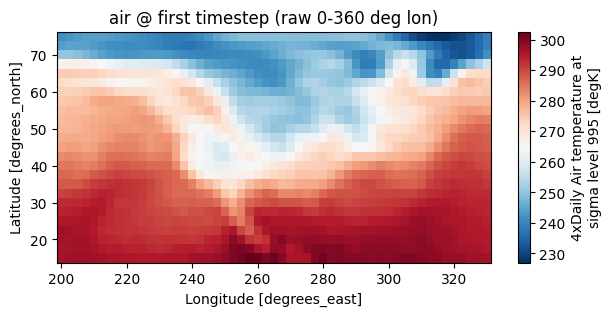

In [4]:
fig, ax = plt.subplots(figsize=(7, 3))
ds.air.isel(time=0).plot(ax=ax, cmap="RdBu_r")
ax.set_title("air @ first timestep (raw 0-360 deg lon)")
plt.show()

## 2. An `Operator` is just a configured callable

Like a keras layer, an `Operator` is an object that holds *configuration*
and exposes `__call__`. The same instance can be reused on many datasets.

In [5]:
validate = ValidateCoords()
print(repr(validate))
print("config:", validate.get_config())

ds_clean = validate(ds)
print("lon range after validate:", float(ds_clean.lon.min()), float(ds_clean.lon.max()))

ValidateCoords()
config: {}
lon range after validate: -160.0 -30.0


Note how `ValidateCoords` flipped the longitudes from `[0, 360)` to
`(-180, 180]`. The rest of the notebook works in the validated convention.

## 3. Composing with `|`

The pipe operator builds a `Sequential` left-to-right. Each step is a
single-input transform on a `Dataset`.

In [6]:
preprocess = (
    ValidateCoords()
    | SubsetBBox(lon_bnds=(-125, -65), lat_bnds=(25, 50))  # CONUS
    | ResampleTime(freq="1D", method="mean")  # 4×/day → daily
)

print(type(preprocess).__name__)
ds_pre = preprocess(ds)
ds_pre

Sequential


<xarray.Dataset> Size: 2MB
Dimensions:  (time: 730, lat: 11, lon: 25)
Coordinates:
  * time     (time) datetime64[ns] 6kB 2013-01-01 2013-01-02 ... 2014-12-31
  * lat      (lat) float32 44B 50.0 47.5 45.0 42.5 40.0 ... 32.5 30.0 27.5 25.0
  * lon      (lon) float32 100B -125.0 -122.5 -120.0 ... -70.0 -67.5 -65.0
Data variables:
    air      (time, lat, lon) float64 2MB 272.0 266.1 262.6 ... 298.3 297.8
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

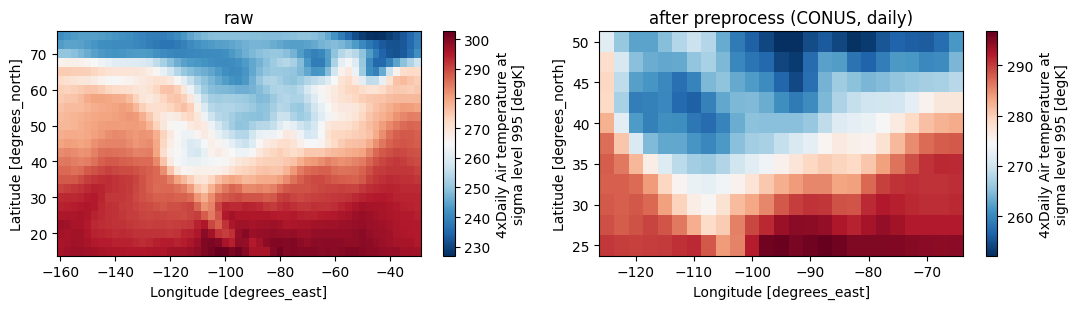

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
ds.air.isel(time=0).plot(ax=axes[0], cmap="RdBu_r")
axes[0].set_title("raw")
ds_pre.air.isel(time=0).plot(ax=axes[1], cmap="RdBu_r")
axes[1].set_title("after preprocess (CONUS, daily)")
plt.tight_layout()
plt.show()

## 4. `Sequential` as a "model"

`Sequential([...])` is the explicit form. It exposes `.describe()` (a la
`model.summary()`) and `.get_config()` for serialization.

In [8]:
pipeline = xt.Sequential(
    [
        ValidateCoords(),
        SubsetBBox(lon_bnds=(-125, -65), lat_bnds=(25, 50)),
        ResampleTime(freq="1D", method="mean"),
    ]
)

print(pipeline.describe())

Sequential (3 ops)
├── ValidateCoords()
├── SubsetBBox(lon_bnds=[-125, -65], lat_bnds=[25, 50], lon='lon', lat='lat')
└── ResampleTime(freq='1D', method='mean', time='time')


In [9]:
print(json.dumps(pipeline.get_config(), indent=2))

{
  "operators": [
    {
      "class": "ValidateCoords",
      "config": {}
    },
    {
      "class": "SubsetBBox",
      "config": {
        "lon_bnds": [
          -125,
          -65
        ],
        "lat_bnds": [
          25,
          50
        ],
        "lon": "lon",
        "lat": "lat"
      }
    },
    {
      "class": "ResampleTime",
      "config": {
        "freq": "1D",
        "method": "mean",
        "time": "time"
      }
    }
  ]
}


## 5. Nesting pipelines

Because `Sequential` is itself an `Operator`, pipelines compose. We split
the data into a 2013 "training" year (used to fit a day-of-year
climatology) and a 2014 "test" year, then build an anomaly pipeline that
stacks the preprocessor with the climatology removal.

In [10]:
train = SubsetTime("2013-01-01", "2013-12-31")(ds_pre)
test = SubsetTime("2014-01-01", "2014-12-31")(ds_pre)

clim = CalculateClimatology(freq="day")(train)
print("climatology dims:", dict(clim.sizes))

anomaly_pipeline = preprocess | RemoveClimatology(clim)
print(anomaly_pipeline.describe())

climatology dims: {'dayofyear': 365, 'lat': 11, 'lon': 25}
Sequential (4 ops)
├── ValidateCoords()
├── SubsetBBox(lon_bnds=[-125, -65], lat_bnds=[25, 50], lon='lon', lat='lat')
├── ResampleTime(freq='1D', method='mean', time='time')
└── RemoveClimatology(climatology='<xr object>', time='time')


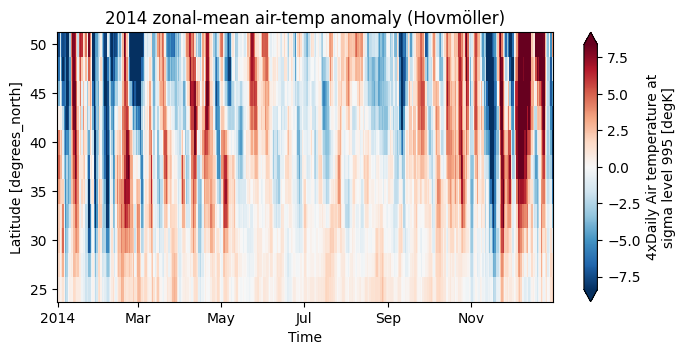

In [11]:
anomalies_2014 = (SubsetTime("2014-01-01", "2014-12-31") | RemoveClimatology(clim))(
    ds_pre
)

fig, ax = plt.subplots(figsize=(8, 3.5))
anomalies_2014.air.mean(dim="lon").plot(
    ax=ax, x="time", y="lat", cmap="RdBu_r", center=0, robust=True
)
ax.set_title("2014 zonal-mean air-temp anomaly (Hovmöller)")
plt.show()

## 6. Metric Operators are just two-input Operators

`xr_toolz` ships pixel metrics (`MSE`, `RMSE`, `MAE`, `Bias`, `Correlation`,
`R2Score`, `PSDScore`) as `Operator` subclasses. Their `_apply` takes two
datasets — a *prediction* and a *reference* — so the call site looks like
`metric(pred, ref)` rather than the single-arg pipeline form.

We build a deliberately weak baseline: predict 2014 with the 2013
climatology. (The point is the **mechanics**, not skill.)

In [12]:
# Build a prediction by adding the climatology onto a zero dataset
# that already has the 2014 time axis.
pred_2014 = AddClimatology(clim)(xr.zeros_like(test))
ref_2014 = test

# Reduce over space → daily RMSE timeseries
rmse_t = RMSE(variable="air", dims=["lat", "lon"])(pred_2014, ref_2014)
# Reduce over time → spatial RMSE map
rmse_map = RMSE(variable="air", dims="time")(pred_2014, ref_2014)

print("daily RMSE timeseries dims:", dict(rmse_t.sizes))
print("spatial RMSE map  dims:", dict(rmse_map.sizes))
print("config:", RMSE(variable="air", dims=["lat", "lon"]).get_config())

daily RMSE timeseries dims: {'time': 365}
spatial RMSE map  dims: {'lat': 11, 'lon': 25}
config: {'variable': 'air', 'dims': ['lat', 'lon']}


In [13]:
metrics = {
    "RMSE": RMSE("air", ["lat", "lon", "time"]),
    "Bias": Bias("air", ["lat", "lon", "time"]),
    "Corr": Correlation("air", ["lat", "lon", "time"]),
}
scores = {
    name: float(np.asarray(op(pred_2014, ref_2014))) for name, op in metrics.items()
}
scores

{'RMSE': 6.026034023457552,
 'Bias': -0.27575987546699765,
 'Corr': 0.8639636737518277}

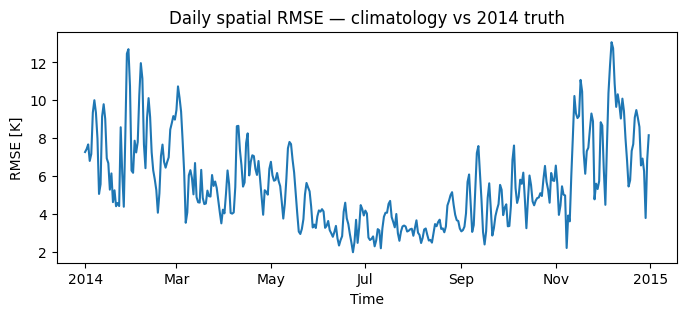

In [14]:
fig, ax = plt.subplots(figsize=(8, 3))
rmse_t.plot(ax=ax)
ax.set_ylabel("RMSE [K]")
ax.set_title("Daily spatial RMSE — climatology vs 2014 truth")
plt.show()

## 7. A plot is also just an Operator

Subclassing `Operator` is the recipe for adding new behavior — exactly the
keras moment when you discover layers are 30 lines. Required parts:

1. `__init__` storing config
2. `_apply(self, *args)` doing the work
3. `get_config()` returning a JSON-serializable dict

Plot Operators are *pass-through*: they do a side-effect (render a figure)
and return the input unchanged so they slot anywhere inside a chain.

In [15]:
class PlotMap(xt.Operator):
    """Render a 2-D field; return the dataset unchanged."""

    def __init__(
        self,
        variable: str,
        *,
        cmap: str = "viridis",
        title: str | None = None,
    ):
        self.variable = variable
        self.cmap = cmap
        self.title = title

    def _apply(self, ds):
        da = ds[self.variable] if isinstance(ds, xr.Dataset) else ds
        if "time" in da.dims:
            da = da.isel(time=0)
        _, ax = plt.subplots(figsize=(6, 3))
        da.plot(ax=ax, cmap=self.cmap)
        ax.set_title(self.title or self.variable)
        plt.show()
        return ds

    def get_config(self):
        return {"variable": self.variable, "cmap": self.cmap, "title": self.title}

**Use 1 — drop it into a chain as a debug "print layer".** Two figures
render in a single pipeline call, before and after the climatology removal.

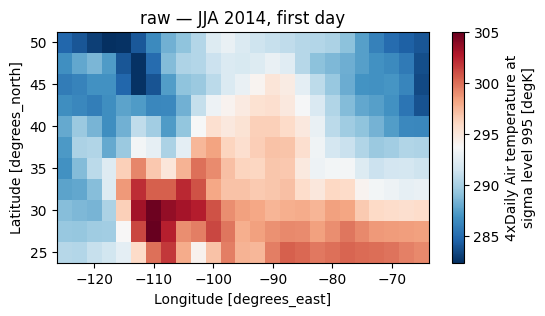

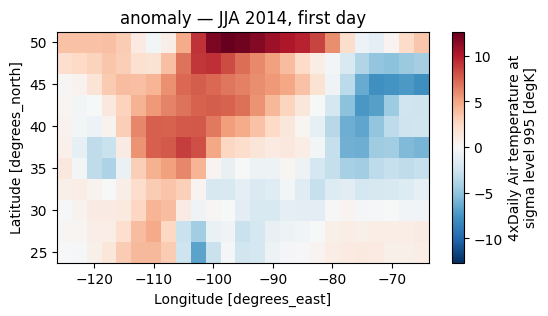

In [16]:
debug_pipeline = (
    SubsetTime("2014-06-01", "2014-08-31")
    | PlotMap("air", cmap="RdBu_r", title="raw — JJA 2014, first day")
    | RemoveClimatology(clim)
    | PlotMap("air", cmap="RdBu_r", title="anomaly — JJA 2014, first day")
)
_ = debug_pipeline(ds_pre)

**Use 2 — visualise a metric Operator's output.** The spatial RMSE map
from §6 is just another `DataArray`, so the same `PlotMap` instance works.

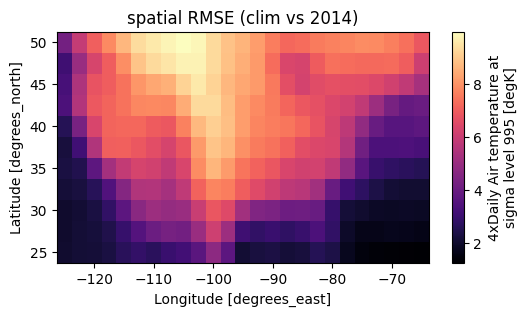

<xarray.DataArray 'air' (lat: 11, lon: 25)> Size: 2kB
array([[4.20669415, 5.90931799, 7.03035283, 7.83791515, 8.68741831,
        9.33819358, 9.59745713, 9.79366763, 9.98589787, 9.82728437,
        9.33147195, 8.88582845, 8.60047135, 8.20618698, 7.6247068 ,
        7.21769749, 7.29424019, 7.59019767, 7.69494503, 7.76096678,
        7.89270678, 7.83801124, 7.64084247, 7.36126088, 6.87196383],
       [3.0792568 , 4.97565103, 6.30945415, 7.00733501, 7.91053627,
        8.89463129, 9.33591523, 9.51601928, 9.78082858, 9.77799695,
        9.33260334, 8.83906471, 8.5146096 , 8.11356262, 7.29695321,
        6.39839616, 6.27217449, 6.95494566, 7.37533263, 7.29923795,
        7.22508802, 7.2475272 , 7.27403648, 6.99714252, 6.06541366],
       [3.25933716, 5.44343134, 6.77149132, 7.00780389, 7.39174722,
        8.06854736, 8.35333819, 8.53439623, 9.18696991, 9.58290068,
        9.19999104, 8.66655839, 8.35765828, 8.13831343, 7.53398477,
        6.63471338, 6.26359568, 6.56036098, 6.70717536, 6.61465772,
        6.59959734, 6.46314501, 6.18231568, 5.83701464, 5.27643827],
       [3.35247109, 5.538591  , 6.89838186, 7.15071281, 7.39198033,
        7.79456132, 7.80436309, 7.77445195, 8.47760731, 9.31107345,
        9.32115498, 8.78432659, 8.20179766, 7.84176417, 7.57239827,
        7.16647416, 6.8762081 , 6.70243016, 6.4331108 , 6.2027253 ,
        5.83847469, 5.10392374, 4.30153757, 3.90034948, 4.00225568],
...
       [2.14923641, 2.24689869, 2.57876695, 3.44174659, 4.55875747,
        5.48185928, 5.54490697, 5.2601195 , 5.80441816, 7.09206373,
        7.7570405 , 7.59652534, 7.00484675, 6.51137629, 6.17105521,
        5.76733753, 5.65107688, 5.1876998 , 3.96230981, 3.10765979,
        2.73578311, 2.35091746, 2.10185548, 2.06115728, 2.04609581],
       [1.9844635 , 2.07796494, 2.28512114, 2.79621531, 3.67471564,
        4.68033658, 5.09184125, 4.92242736, 5.03117419, 5.99963953,
        6.81516653, 6.47125921, 5.19997758, 4.48496283, 4.35504659,
        4.07554551, 4.10510991, 3.96472715, 2.91384022, 2.14813629,
        2.0161851 , 1.8795027 , 1.85737091, 1.88035917, 1.83482667],
       [1.97711238, 2.11322913, 2.18717386, 2.43859179, 2.91404367,
        3.5290617 , 4.03640381, 4.26124155, 4.15677806, 5.02024537,
        6.12405504, 5.07530369, 3.0688213 , 2.79272762, 2.97000259,
        2.7683506 , 2.9270735 , 3.34250093, 2.79092201, 1.91305906,
        1.63637028, 1.62864767, 1.69471531, 1.68255808, 1.61016867],
       [2.01065382, 2.11878605, 2.14721054, 2.27237573, 2.63629089,
        2.83848623, 2.67841131, 2.9677228 , 3.12706054, 3.6424109 ,
        4.73852794, 3.67754322, 2.08514568, 2.26078284, 2.32210005,
        2.13564771, 2.22454001, 2.56201586, 2.33889685, 1.75637108,
        1.48082464, 1.36525665, 1.34753299, 1.30643519, 1.24622272]])
Coordinates:
  * lat      (lat) float32 44B 50.0 47.5 45.0 42.5 40.0 ... 32.5 30.0 27.5 25.0
  * lon      (lon) float32 100B -125.0 -122.5 -120.0 ... -70.0 -67.5 -65.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

In [17]:
PlotMap(variable="air", cmap="magma", title="spatial RMSE (clim vs 2014)")(rmse_map)

**`get_config()` works the same as the built-in operators.**

In [18]:
PlotMap("air", cmap="magma").get_config()

{'variable': 'air', 'cmap': 'magma', 'title': None}

## 8. Stretch — `Graph` for branching

When the pipeline isn't a straight line — e.g. you want to fan out from a
shared preprocessed input into several heads — switch to the functional
`Graph` API. Operators are reused; calling them on `Node`s builds a DAG
instead of executing eagerly.

In [19]:
from xr_toolz import Graph, Input


raw = Input(name="raw")
pre_node = preprocess(raw)
test_node = SubsetTime("2014-01-01", "2014-12-31")(pre_node)
anomaly_node = RemoveClimatology(clim)(test_node)

graph = Graph(
    inputs={"raw": raw},
    outputs={"test": test_node, "anomaly": anomaly_node},
)

results = graph(raw=ds)
print("outputs:", list(results))
print("test    air mean:", float(results["test"].air.mean()))
print("anomaly air mean:", float(results["anomaly"].air.mean()))

outputs: ['test', 'anomaly']
test    air mean: 286.38612575342466
anomaly air mean: 0.27575987546699765


## Wrap-up

What we covered, in keras vocabulary:

- **Operator** — configured callable; same role as a keras `Layer`.
- **`|`** — pipe sugar that returns a `Sequential`.
- **`Sequential`** — linear pipeline; itself an `Operator`, so it nests.
- **`get_config()` / `.describe()`** — introspection contract every Operator
  honours, including ones you write.
- **Two-input Operators** — metrics (`RMSE`, `Bias`, ...) take
  `(pred, ref)`. They have the same config shape as single-input ops.
- **Pass-through Operators** — `PlotMap` returns its input unchanged so it
  drops into any chain as a debug/visualisation step.
- **`Graph`** — for non-linear pipelines (multiple inputs, fan-out, fan-in).

The recipe for new behavior is always the same: subclass `Operator`,
implement `_apply`, return a JSON-serializable `get_config()`, and you're
automatically composable with everything else in `xr_toolz`.